In [ ]:
!pip install scikit-learn scipy joblib umap-learn -q


In [ ]:
# ── Cell 2 : Imports & Configuration ─────────────────────────────────────────
import os
import sys
import warnings
import hashlib
import time
import tracemalloc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from scipy.stats import wilcoxon, pearsonr, spearmanr, randint as sp_randint
from joblib import dump, load

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    warnings.warn('umap-learn not found — UMAP skipped.', ImportWarning)

SEED = 42
np.random.seed(SEED)

DATASET_PATH = os.environ.get('DATASET_PATH', '/dataset_encoded_normalized1.csv')

N_SPLITS_CV = 5

CACHE_DIR = 'cache_classical_ensemble_pub'
os.makedirs(CACHE_DIR, exist_ok=True)
FIGDIR = os.path.join(CACHE_DIR, 'figures')
os.makedirs(FIGDIR, exist_ok=True)

print(f'Python      : {sys.version.split()[0]}')
print(f'scikit-learn: {__import__("sklearn").__version__}')
print(f'Dataset     : {DATASET_PATH}')
print(f'Cache       : {os.path.abspath(CACHE_DIR)}')


/home/host1-vm4/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python      : 3.13.11
scikit-learn: 1.8.0
Dataset     : /home/host1-vm4/Downloads/dataset_encoded_normalized1.csv
Cache       : /home/host1-vm4/cache_classical_ensemble_pub


In [ ]:
# ── Cell 3 : Data Loading & 3-Way Split (70 / 15 / 15) ───────────────────────


assert os.path.exists(DATASET_PATH), (
    f'Dataset not found at "{DATASET_PATH}". '
    f'Set DATASET_PATH env variable or update the default path.'
)

df = pd.read_csv(DATASET_PATH)
assert 'LN_IC50' in df.columns, "Target column 'LN_IC50' not found."

X_raw = df.drop(columns=['LN_IC50']).values.astype(np.float64)
Y     = df['LN_IC50'].values.astype(np.float64)

N_FEATURES = X_raw.shape[1]
HASH = hashlib.md5(X_raw.data.tobytes()).hexdigest()[:8]

X_tr_r, X_temp, Y_train, Y_temp = train_test_split(
    X_raw, Y, test_size=0.30, random_state=SEED, shuffle=True
)
X_val_r, X_test_r, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.50, random_state=SEED
)

# No quantum encoding — raw features used directly
X_train = X_tr_r
X_val   = X_val_r
X_test  = X_test_r

Y_trainval = np.concatenate([Y_train, Y_val])
X_trainval = np.vstack([X_train, X_val])

print(f'Dataset  : {X_raw.shape[0]} × {N_FEATURES}  |  Hash: {HASH}')
print(f'Split    : Train={X_train.shape[0]}  Val={X_val.shape[0]}  Test={X_test.shape[0]}')
print(f'Target   : mean={Y.mean():.3f}  std={Y.std():.3f}')
print('X_test will be touched ONCE at the final evaluation cell.')


Dataset  : 13106 × 12  |  Hash: 8f057170
Split    : Train=9174  Val=1966  Test=1966
Target   : mean=0.538  std=0.134
X_test will be touched ONCE at the final evaluation cell.


In [ ]:
# ── Cell 4 : Base Learner Definitions & RandomizedSearchCV  ─────────


DT_PARAMS = {
    'max_depth':         [3, 5, 7, 10, None],
    'min_samples_split': sp_randint(2, 20),
    'min_samples_leaf':  sp_randint(1, 10),
    'max_features':      ['sqrt', 'log2', None],
}
RF_PARAMS = {
    'n_estimators':      sp_randint(50, 300),
    'max_depth':         [3, 5, 7, 10, None],
    'min_samples_split': sp_randint(2, 20),
    'min_samples_leaf':  sp_randint(1, 10),
    'max_features':      ['sqrt', 'log2', 0.5],
}
MLP_PARAMS = {
    'mlp__hidden_layer_sizes': [(64,), (128, 64), (64, 32), (128,), (64, 64)],
    'mlp__activation':         ['relu', 'tanh'],
    'mlp__learning_rate_init': [0.001, 0.0005, 0.0001],
    'mlp__alpha':              [1e-4, 1e-3, 1e-5],
    'mlp__max_iter':           [500],
    'mlp__early_stopping':     [True],
    'mlp__random_state':       [SEED],
}

DT_CACHE  = os.path.join(CACHE_DIR, 'base_dt.joblib')
RF_CACHE  = os.path.join(CACHE_DIR, 'base_rf.joblib')
MLP_CACHE = os.path.join(CACHE_DIR, 'base_mlp.joblib')


def tune_base_learner(clf, params, Xtr, Ytr, label, cache_file, n_iter=20):
    if os.path.exists(cache_file):
        print(f'  [{label}] Loaded from cache.')
        return load(cache_file)
    print(f'  [{label}] RandomizedSearchCV ({n_iter} iter, {N_SPLITS_CV}-fold)...')
    search = RandomizedSearchCV(
        clf, params, n_iter=n_iter,
        scoring='neg_mean_squared_error',
        cv=N_SPLITS_CV, random_state=SEED, n_jobs=-1, verbose=0
    )
    search.fit(Xtr, Ytr)
    best = search.best_estimator_
    dump(best, cache_file)
    print(f'  [{label}] Best params : {search.best_params_}')
    print(f'  [{label}] Best CV MSE : {-search.best_score_:.4f}')
    return best


print('Tuning base learners (RandomizedSearchCV)...')
tuned_dt  = tune_base_learner(
    DecisionTreeRegressor(random_state=SEED),
    DT_PARAMS, X_train, Y_train, 'DT', DT_CACHE, n_iter=20)

tuned_rf  = tune_base_learner(
    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    RF_PARAMS, X_train, Y_train, 'RF', RF_CACHE, n_iter=20)

tuned_mlp = tune_base_learner(
    Pipeline([('scaler', StandardScaler()), ('mlp', MLPRegressor())]),
    MLP_PARAMS, X_train, Y_train, 'MLP', MLP_CACHE, n_iter=20)

BASE_LEARNERS = [('dt', tuned_dt), ('rf', tuned_rf), ('mlp', tuned_mlp)]
print('\nAll base learners ready.')


Tuning base learners (RandomizedSearchCV)...
  [DT] RandomizedSearchCV (20 iter, 5-fold)...
  [DT] Best params : {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 16}
  [DT] Best CV MSE : 0.0042
  [RF] RandomizedSearchCV (20 iter, 5-fold)...
  [RF] Best params : {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 58}
  [RF] Best CV MSE : 0.0021
  [MLP] RandomizedSearchCV (20 iter, 5-fold)...
  [MLP] Best params : {'mlp__random_state': 42, 'mlp__max_iter': 500, 'mlp__learning_rate_init': 0.001, 'mlp__hidden_layer_sizes': (128, 64), 'mlp__early_stopping': True, 'mlp__alpha': 0.001, 'mlp__activation': 'relu'}
  [MLP] Best CV MSE : 0.0049

All base learners ready.


In [ ]:
# ── Cell 5 : 5-Fold OOF Stacking Meta-Features ───────────────────────────────
#
# OOF sur (train+val)


kf = KFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=SEED)
oof_preds = {name: np.zeros(len(Y_trainval)) for name, _ in BASE_LEARNERS}

print(f'Generating {N_SPLITS_CV}-fold OOF meta-features...')
for fold, (tr_idx, vl_idx) in enumerate(kf.split(X_trainval)):
    for clf_name, clf_template in BASE_LEARNERS:
        m = clone(clf_template)
        m.fit(X_trainval[tr_idx], Y_trainval[tr_idx])
        oof_preds[clf_name][vl_idx] = m.predict(X_trainval[vl_idx])
    print(f'  Fold {fold+1}/{N_SPLITS_CV} done')

X_meta_train = np.column_stack([oof_preds[n] for n, _ in BASE_LEARNERS])
print(f'Meta-train shape: {X_meta_train.shape}  (columns: {[n for n,_ in BASE_LEARNERS]})')

# Train final base learners on full trainval for test prediction
trained_base = {}
for clf_name, clf_template in BASE_LEARNERS:
    m = clone(clf_template)
    m.fit(X_trainval, Y_trainval)
    trained_base[clf_name] = m

X_meta_test = np.column_stack([
    trained_base[n].predict(X_test) for n, _ in BASE_LEARNERS
])
print(f'Meta-test shape: {X_meta_test.shape}')


Generating 5-fold OOF meta-features...
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done
Meta-train shape: (11140, 3)  (columns: ['dt', 'rf', 'mlp'])
Meta-test shape: (1966, 3)


In [ ]:
# ── Cell 6 : GBM Meta-Learner (RandomizedSearchCV, cv=5) ─────────────────────

GBM_CACHE = os.path.join(CACHE_DIR, 'meta_gbm.joblib')
GBM_PARAMS = {
    'n_estimators':      [50, 100, 200, 300],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'max_depth':         [2, 3, 4, 5],
    'subsample':         [0.7, 0.8, 1.0],
    'min_samples_split': [2, 5, 10],
}

if os.path.exists(GBM_CACHE):
    meta_gbm = load(GBM_CACHE)
    print('GBM meta-learner loaded from cache.')
else:
    print(f'Tuning GBM meta-learner (RandomizedSearchCV, 30 iter, {N_SPLITS_CV}-fold)...')
    s = RandomizedSearchCV(
        GradientBoostingRegressor(random_state=SEED),
        GBM_PARAMS, n_iter=30,
        scoring='neg_mean_squared_error',
        cv=N_SPLITS_CV, random_state=SEED, n_jobs=-1, verbose=0
    )
    s.fit(X_meta_train, Y_trainval)
    meta_gbm = s.best_estimator_
    dump(meta_gbm, GBM_CACHE)
    print(f'  Best params: {s.best_params_}')
    print(f'  Best CV MSE: {-s.best_score_:.6f}')


Tuning GBM meta-learner (RandomizedSearchCV, 30 iter, 5-fold)...
  Best params: {'subsample': 0.7, 'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 4, 'learning_rate': 0.05}
  Best CV MSE: 0.001688


In [ ]:
# ── Cell 7 : RF Meta-Learner (RandomizedSearchCV, cv=5) ──────────────────────

RF_META_CACHE  = os.path.join(CACHE_DIR, 'meta_rf.joblib')
RF_META_PARAMS = {
    'n_estimators':      [50, 100, 200, 300],
    'max_depth':         [None, 3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
}

if os.path.exists(RF_META_CACHE):
    meta_rf = load(RF_META_CACHE)
    print('RF meta-learner loaded from cache.')
else:
    print(f'Tuning RF meta-learner (RandomizedSearchCV, 20 iter, {N_SPLITS_CV}-fold)...')
    s = RandomizedSearchCV(
        RandomForestRegressor(random_state=SEED, n_jobs=-1),
        RF_META_PARAMS, n_iter=20,
        scoring='neg_mean_squared_error',
        cv=N_SPLITS_CV, random_state=SEED, n_jobs=-1, verbose=0
    )
    s.fit(X_meta_train, Y_trainval)
    meta_rf = s.best_estimator_
    dump(meta_rf, RF_META_CACHE)
    print(f'  Best params: {s.best_params_}')
    print(f'  Best CV MSE: {-s.best_score_:.6f}')


Tuning RF meta-learner (RandomizedSearchCV, 20 iter, 5-fold)...
  Best params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
  Best CV MSE: 0.001761


In [ ]:
# ── Cell 8 : Final Holdout Evaluation — X_test touched ONCE ──────────────────


def eval_model(model, X_te, Y_te, label, optimizer='—'):
    """Uniform evaluation across all models."""
    tracemalloc.start()
    t0      = time.time()
    Y_pred  = model.predict(X_te)
    elapsed = time.time() - t0
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    pr, _ = pearsonr(Y_te, Y_pred)
    sr, _ = spearmanr(Y_te, Y_pred)
    return {
        'Model':        label,
        'MSE':          mean_squared_error(Y_te, Y_pred),
        'RMSE':         np.sqrt(mean_squared_error(Y_te, Y_pred)),
        'MAE':          mean_absolute_error(Y_te, Y_pred),
        'R2':           r2_score(Y_te, Y_pred),
        'Pearson r':    round(pr, 4),
        'Spearman rho': round(sr, 4),
        'Time (s)':     round(elapsed, 4),
        'Memory (MB)':  round(peak / 1024**2, 4),
        'Optimizer':    optimizer,
        '_pred':        Y_pred,
    }


print('Final evaluation on X_test (touched once):')
rows = []

for clf_name, _ in BASE_LEARNERS:
    r = eval_model(
        trained_base[clf_name], X_test, Y_test,
        label=f'Classical {clf_name.upper()} (base)',
        optimizer='RandomizedSearchCV'
    )
    rows.append(r)

res_gbm = eval_model(meta_gbm, X_meta_test, Y_test,
                     label='Stacking — GBM meta',
                     optimizer='RandomizedSearchCV (30 iter, 5-fold)')
res_rf  = eval_model(meta_rf,  X_meta_test, Y_test,
                     label='Stacking — RF meta',
                     optimizer='RandomizedSearchCV (20 iter, 5-fold)')
rows += [res_gbm, res_rf]

preds      = {r['Model']: r.pop('_pred') for r in rows}
results_df = pd.DataFrame(rows).set_index('Model')
display_cols = ['MSE', 'RMSE', 'MAE', 'R2', 'Pearson r', 'Spearman rho',
                'Time (s)', 'Memory (MB)', 'Optimizer']

print('\n── Test Set Results (Classical Baseline) ──')
print(results_df[display_cols].round(4).to_string())


Final evaluation on X_test (touched once):

── Test Set Results (Classical Baseline) ──
                         MSE    RMSE     MAE      R2  Pearson r  Spearman rho  Time (s)  Memory (MB)                             Optimizer
Model                                                                                                                                     
Classical DT (base)   0.0041  0.0637  0.0429  0.7877     0.8877        0.8480    0.0015       0.1271                    RandomizedSearchCV
Classical RF (base)   0.0016  0.0404  0.0265  0.9145     0.9574        0.9437    0.1011       0.3738                    RandomizedSearchCV
Classical MLP (base)  0.0042  0.0645  0.0462  0.7823     0.8849        0.8523    0.0105       3.0614                    RandomizedSearchCV
Stacking — GBM meta   0.0014  0.0372  0.0244  0.9274     0.9631        0.9466    0.0315       0.0536  RandomizedSearchCV (30 iter, 5-fold)
Stacking — RF meta    0.0015  0.0388  0.0259  0.9212     0.9598        0.9435 

In [ ]:
# ── Cell 9 : Wilcoxon Test — Stacking GBM vs Best Base ───────────────────────

r2_oof = {n: r2_score(Y_trainval, oof_preds[n]) for n, _ in BASE_LEARNERS}
best_base_name = max(r2_oof, key=r2_oof.get)
print(f'OOF R² per base: {r2_oof}')
print(f'Best base learner: {best_base_name.upper()}')

mse_gbm_folds, mse_best_folds = [], []
for fold, (tr_idx, vl_idx) in enumerate(kf.split(X_meta_train)):
    m = clone(meta_gbm)
    m.fit(X_meta_train[tr_idx], Y_trainval[tr_idx])
    mse_gbm_folds.append(mean_squared_error(Y_trainval[vl_idx], m.predict(X_meta_train[vl_idx])))
    mse_best_folds.append(mean_squared_error(Y_trainval[vl_idx], oof_preds[best_base_name][vl_idx]))

stat, p_val = wilcoxon(mse_best_folds, mse_gbm_folds, alternative='greater')
print(f'\n── Wilcoxon: Stacking GBM vs {best_base_name.upper()} ──')
print(f'  stat={stat:.3f}  p={p_val:.4f}  '
      f'{"significant (p<0.05)" if p_val < 0.05 else "not significant"}')

from scipy.stats import norm as _norm
n_pairs  = len(mse_best_folds)
z_approx = _norm.ppf(1 - p_val) if p_val < 1 else 0.0
r_effect = abs(z_approx) / np.sqrt(n_pairs)
print(f'  Effect size r = |Z|/sqrt(N) ≈ {r_effect:.3f}  (small<0.1, medium<0.3, large≥0.5)')


OOF R² per base: {'dt': 0.7785714868688463, 'rf': 0.8912147348597264, 'mlp': 0.740854337374784}
Best base learner: RF

── Wilcoxon: Stacking GBM vs RF ──
  stat=15.000  p=0.0312  significant (p<0.05)
  Effect size r = |Z|/sqrt(N) ≈ 0.833  (small<0.1, medium<0.3, large≥0.5)


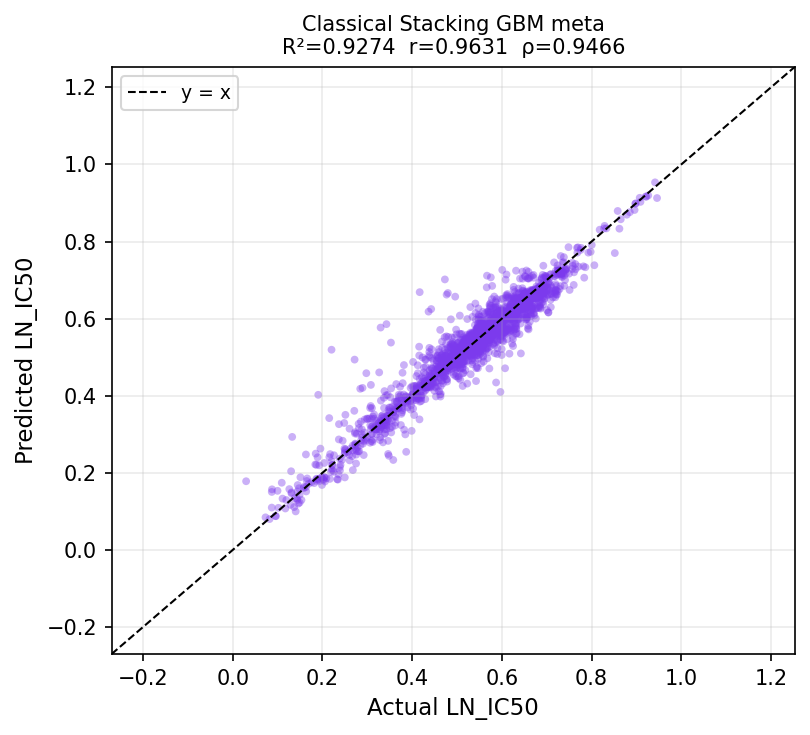

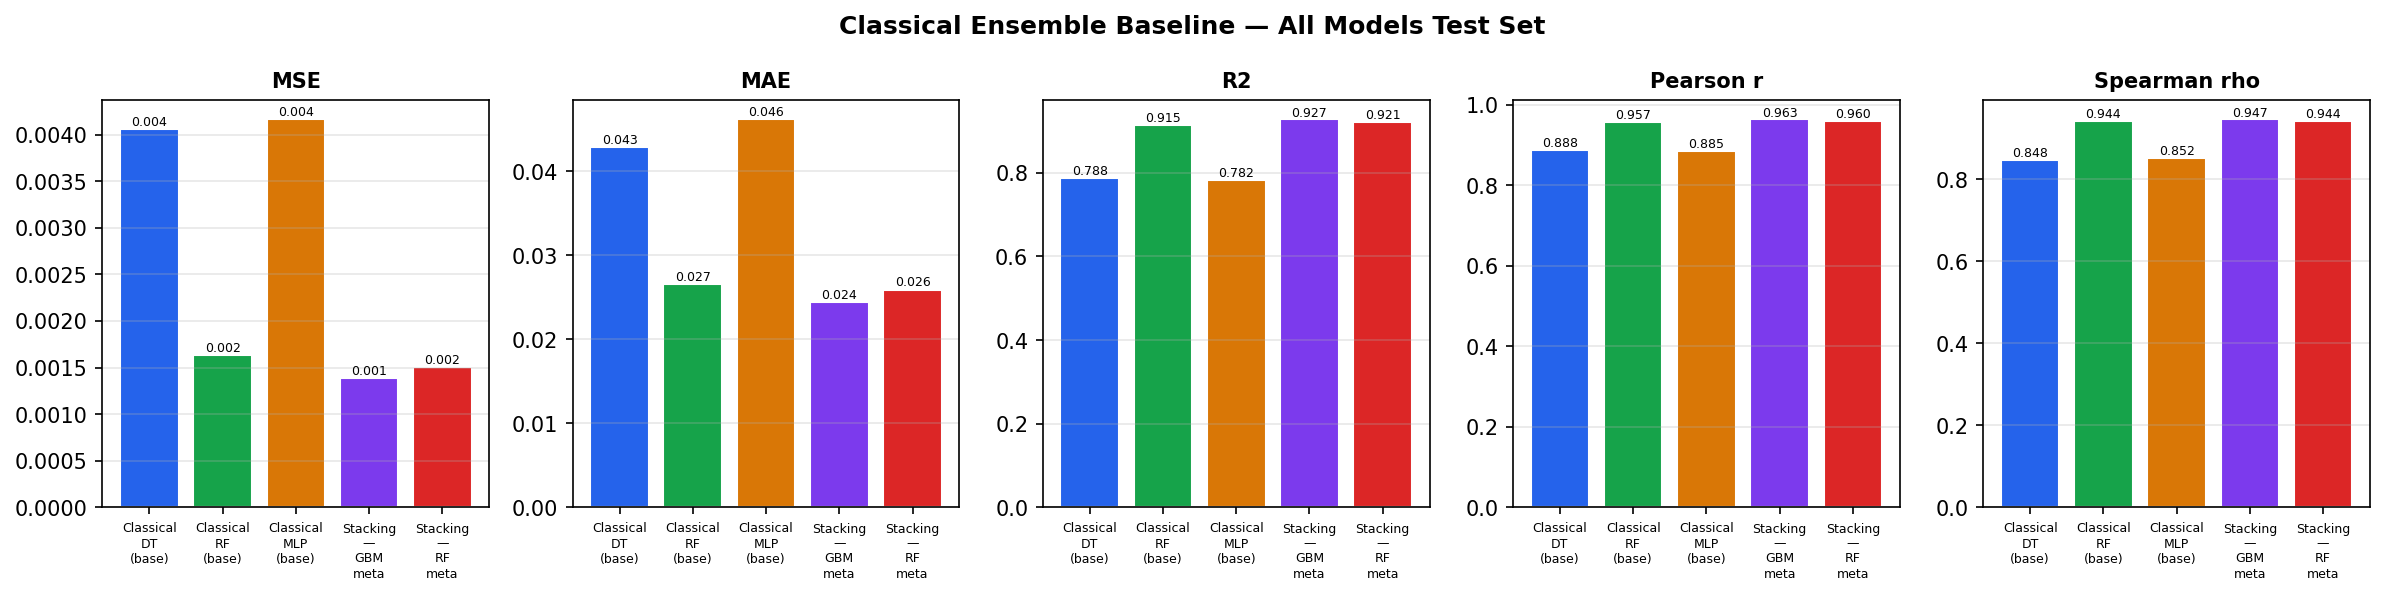

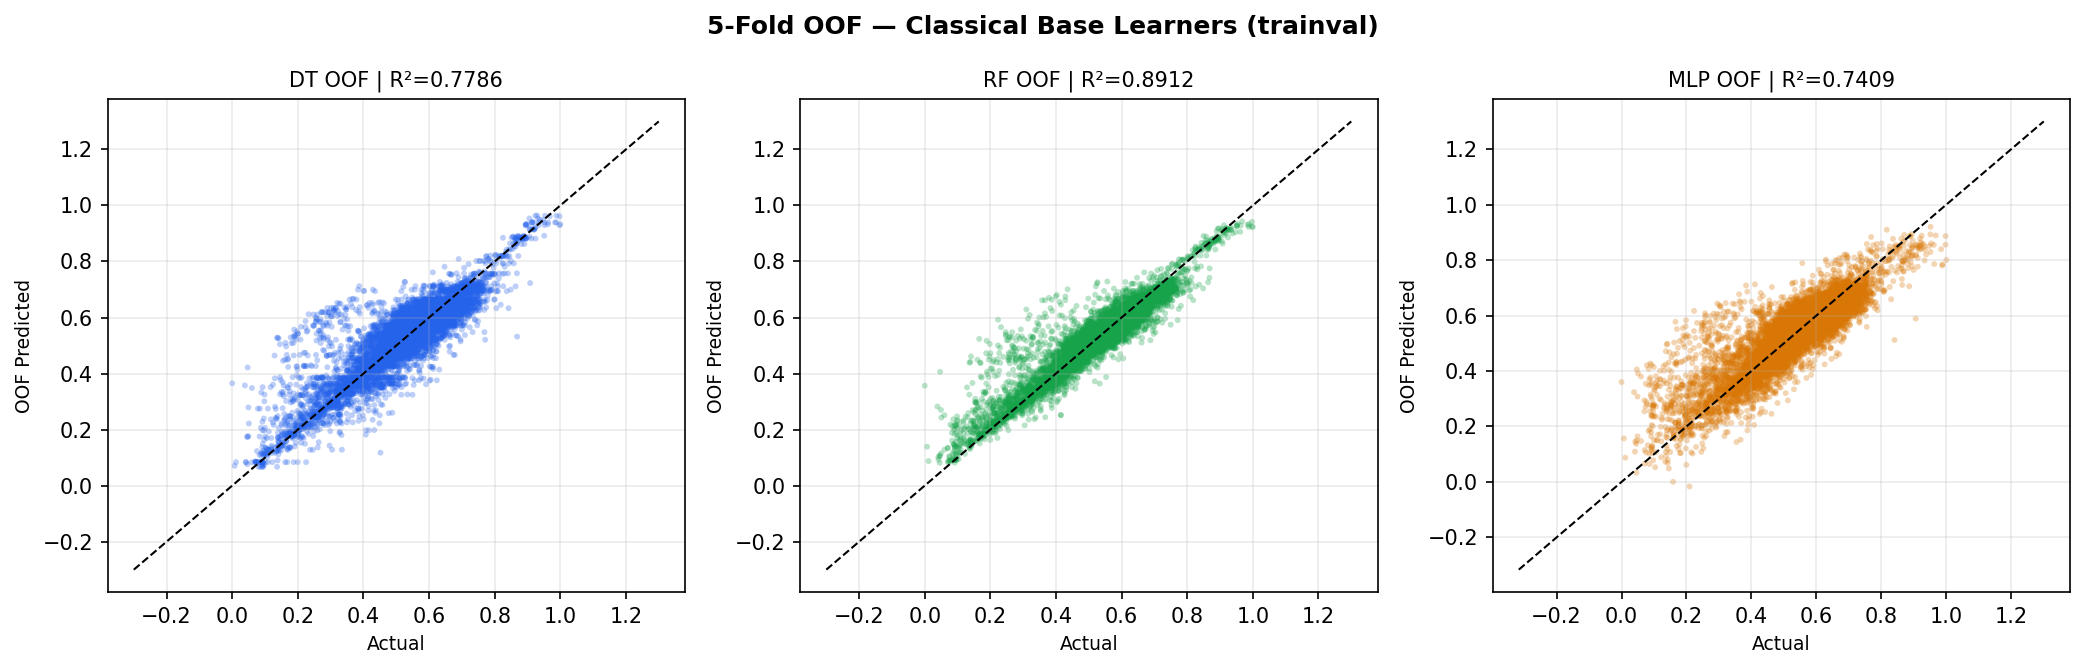

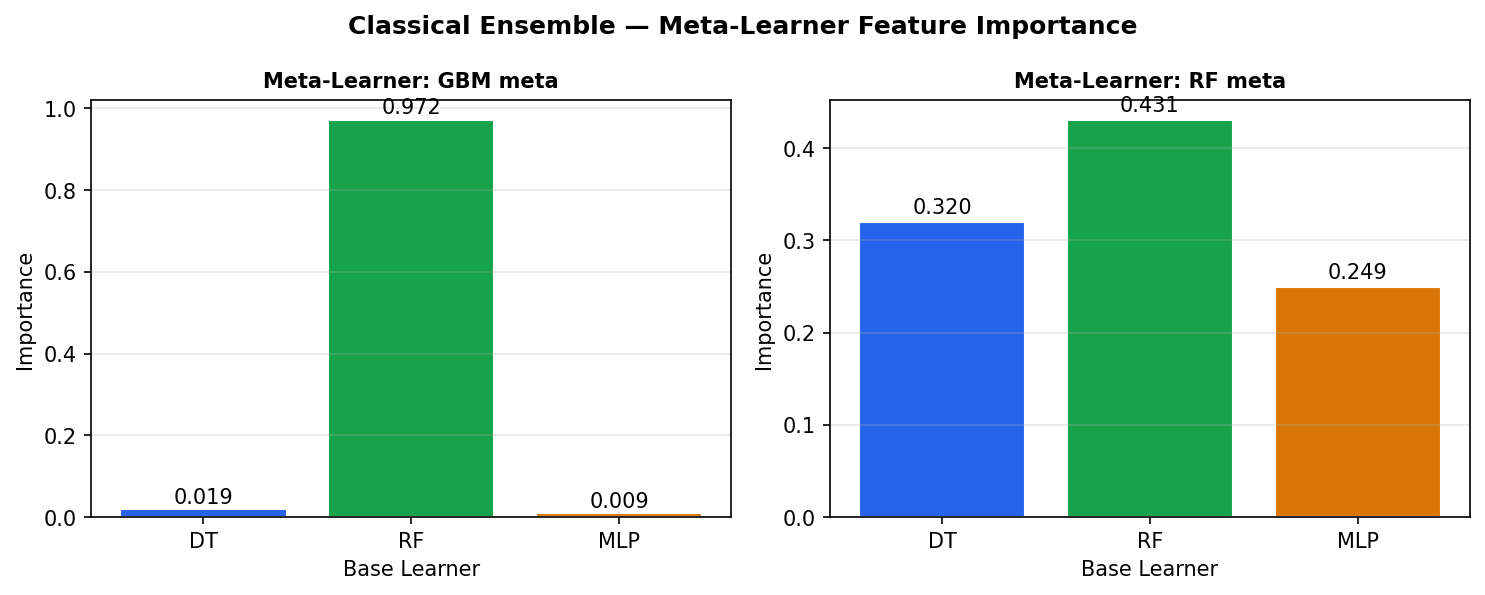

Figures saved to /home/host1-vm4/cache_classical_ensemble_pub/figures


In [ ]:
# ── Cell 10 : Publication Figures ────────────────────────────────────────────

MODEL_COLORS = {
    'Classical DT (base)':  '#2563EB',
    'Classical RF (base)':  '#16A34A',
    'Classical MLP (base)': '#D97706',
    'Stacking — GBM meta':  '#7C3AED',
    'Stacking — RF meta':   '#DC2626',
}

# Figure 1: Predicted vs Actual — GBM stacking
y_gbm = preds['Stacking — GBM meta']
fig, ax = plt.subplots(figsize=(5.5, 5), dpi=150)
lims = [min(Y_test.min(), y_gbm.min()) - 0.3, max(Y_test.max(), y_gbm.max()) + 0.3]
ax.scatter(Y_test, y_gbm, alpha=0.4, s=14, color='#7C3AED', edgecolors='none')
ax.plot(lims, lims, 'k--', lw=1, label='y = x')
ax.set_xlim(lims); ax.set_ylim(lims)
r2v = results_df.loc['Stacking — GBM meta', 'R2']
prv = results_df.loc['Stacking — GBM meta', 'Pearson r']
srv = results_df.loc['Stacking — GBM meta', 'Spearman rho']
ax.set_title(f'Classical Stacking GBM meta\nR²={r2v:.4f}  r={prv:.4f}  ρ={srv:.4f}', fontsize=10)
ax.set_xlabel('Actual LN_IC50', fontsize=11)
ax.set_ylabel('Predicted LN_IC50', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig1_pred_vs_actual_stack.png'), dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: All models metrics bar
metrics_bar  = ['MSE', 'MAE', 'R2', 'Pearson r', 'Spearman rho']
model_labels = results_df.index.tolist()
colors       = [MODEL_COLORS.get(l, '#888888') for l in model_labels]

fig, axes = plt.subplots(1, len(metrics_bar), figsize=(16, 4), dpi=150)
for ax, metric in zip(axes, metrics_bar):
    vals = results_df[metric].values
    bars = ax.bar(range(len(model_labels)), vals, color=colors, edgecolor='white')
    ax.set_xticks(range(len(model_labels)))
    ax.set_xticklabels([l.replace(' ', '\n') for l in model_labels], fontsize=6)
    ax.set_title(metric, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003 * abs(max(vals) - min(vals)),
                f'{val:.3f}', ha='center', va='bottom', fontsize=6)

plt.suptitle('Classical Ensemble Baseline — All Models Test Set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig2_metrics_bar.png'), dpi=300, bbox_inches='tight')
plt.show()

# Figure 3: OOF scatter (base learners)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), dpi=150)
for ax, (clf_name, _) in zip(axes, BASE_LEARNERS):
    oof_p = oof_preds[clf_name]
    r2v   = r2_score(Y_trainval, oof_p)
    lims  = [min(Y_trainval.min(), oof_p.min()) - 0.3, max(Y_trainval.max(), oof_p.max()) + 0.3]
    ax.scatter(Y_trainval, oof_p, alpha=0.3, s=8,
               color=MODEL_COLORS.get(f'Classical {clf_name.upper()} (base)', '#888'), edgecolors='none')
    ax.plot(lims, lims, 'k--', lw=1)
    ax.set_title(f'{clf_name.upper()} OOF | R²={r2v:.4f}', fontsize=10)
    ax.set_xlabel('Actual', fontsize=9); ax.set_ylabel('OOF Predicted', fontsize=9)
    ax.grid(True, alpha=0.25)

plt.suptitle(f'{N_SPLITS_CV}-Fold OOF — Classical Base Learners (trainval)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig3_oof_scatter.png'), dpi=300, bbox_inches='tight')
plt.show()

# Figure 4: Meta-learner feature importance
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=150)
learner_names = [n.upper() for n, _ in BASE_LEARNERS]
meta_colors   = ['#2563EB', '#16A34A', '#D97706']
for ax, (meta_model, meta_label) in zip(axes, [(meta_gbm, 'GBM meta'), (meta_rf, 'RF meta')]):
    imp  = meta_model.feature_importances_
    bars = ax.bar(learner_names, imp, color=meta_colors, edgecolor='white')
    ax.set_xlabel('Base Learner', fontsize=10)
    ax.set_ylabel('Importance', fontsize=10)
    ax.set_title(f'Meta-Learner: {meta_label}', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, imp):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Classical Ensemble — Meta-Learner Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig4_meta_importance.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f'Figures saved to {os.path.abspath(FIGDIR)}')
